In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO


pep_hits_long = pd.read_csv('long_091826.csv')

In [2]:
cchfv = pep_hits_long[pep_hits_long['species'] == 'Orthonairovirus haemorrhagiae'].copy()

## importing the reference sequences fetched from UniProt UP000008767

In [3]:
records = list(SeqIO.parse('UP000008767_2026_09_21_CCHFV_reference.fasta', 'fasta'))

for r in records:
    print(r.id, len(r.seq))

sp|P89522|NCAP_CCHFI 482
sp|Q6TQR6|L_CCHFI 3945
sp|Q8JSZ3|GP_CCHFI 1684
sp|P0DTL3|NSS_CCHFI 150


In [4]:
reference_by_protein = {
    "polymerase": str(next(r.seq for r in records if "Q6TQR6" in r.id)),
    "glycoprotein": str(next(r.seq for r in records if "Q8JSZ3" in r.id)),
    "nucleoprotein": str(next(r.seq for r in records if "P89522" in r.id)),
    "NSs": str(next(r.seq for r in records if "P0DTL3" in r.id)),
}

In [5]:
print(cchfv['category'].value_counts())
print(cchfv['sequence'].nunique())
print(cchfv['protein_std'].unique())

category
Household contact    10803
Lassa survivor        4680
US healthy            3393
Name: count, dtype: int64
39
['glycoprotein' 'polymerase' 'nucleoprotein']


## import PairwiseAligner and use BLOSUM62 matrix for local protein alignment

In [6]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

aligner = PairwiseAligner()
aligner.mode = 'local' #want the peptide to find its best location within the reference

aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

## polymerase

In [7]:
ref = reference_by_protein['polymerase']

gp = cchfv[cchfv['protein_std'].eq("polymerase")].copy()

unique_gp_peptides = gp['sequence'].drop_duplicates()

In [8]:
ref

'MDFLRSLDWTQVIAGQYVSNPRFNISDYFEIVRQPGDGNCFYHSIAELTMPNKTDHSYHYIKRLTESAARKYYQEEPEARLVGLSLEDYLKRMLSDNEWGSTLEASMLAKEMGITIIIWTVAASDEVEAGIKFGDGDVFTAVNLLHSGQTHFDALRILPQFETDTREALSLMDRVIAVDQLTSSSSDELQDYEDLALALTSAEESNRRSSLDEVTLSKKQAEILRQKASQLSKLVNKSQNIPTRVGRVLDCMFNCKLCVEISADTLILRPESKEKIGEIMSLRQLGHKLLTRDKQIKQEFSRMKLYVTKDLLDHLDVGGLLRAAFPGTGIERHMQLLHSEMILDICTVSLGVMLSTFLYGSNNKNKKKFITNCLLSTALSGKKVYKVLGNLGNELLYKAPRKALATVCSALFGKQINKLQNCFRTISPVSLLALRNLDFDCLSVQDYNGMIENMSKLDNTDVEFNHREIADLNQLTSRLITLRKEKDTDLLKQWFPESDLTRRSIRNAANAEEFVISEFFKKKDIMKFISTSGRAMSAGKIGNVLSYAHNLYLSKSSLNMTSEDISQLLIEIKRLYALQEDSEVEPIAIICDGIESNMKQLFAILPPDCARECEVLFDDIRNSPTHSTAWKHALRLKGTAYEGLFANCYGWQYIPEDIKPSLTMLIQTLFPDKFEDFLDRTQLHPEFRDLTPDFSLTQKVHFKRNQIPSVENVQISIDATLPESVEAVPVTERKMFPLPETPLSEVHSIERIMENFTRLMHGGRLSTKKRDGDPAEQGNQQSITEHESSSISAFKDYGERGIVEENHMKFSGEDQLETRQLLLVEVGFQTDIDGKIRTDHKKWKDILKLLELLGIKCSFIACADCSSTPPDRWWITEDRVRVLKNSVSFLFNKLSRNSPTEVTDIVVGAISTQKVRSYLKAGTATKTPVSTKDVLETWEKMKEHILNRPTGLTLPTSLEQAMRKGLVEGVVISKEGSESCINMLKENLDRITDEFERTK

## define mapping function -> sticking to local alignment

In [9]:
def map_peptide_to_reference(peptide, reference, aligner):
    """
    goal: map a peptide onto a reference protein. 

    output: returns a dictionary containing
    - alignment score
    - reference start/end (1-based)
    - reference positions covered by aligned peptide residues
    """

    #if no exact substring match, use local alignment
    alignment = aligner.align(reference, peptide)[0] #[0] to extract the first and best-scoring Alignment object from the results

    #aligner.align[0].aligned returns the start and end coordinates of the aligned segments for the target and query sequences
    ref_blocks, peptide_blocks = alignment.aligned

    ref_positions = []

    for (ref_start, ref_end), (pep_start, pep_end) in zip(ref_blocks, peptide_blocks):
        
        for i in range(ref_end - ref_start):
            ref_positions.append(ref_start + i + 1) #1-based

    #overall peptide coordinates
    pep_start = peptide_blocks[0][0] + 1
    pep_end = peptide_blocks[-1][1] #take the last block,so -1, in case there are more than one aligned blocks. and [1] for the end

    #total number of peptide residues included in the aligned blocks
    aligned_length = sum(end - start for start, end in peptide_blocks)

    #total number 

    return{
        'score': alignment.score, 
        'ref_start': ref_positions[0],
        'ref_end': ref_positions[-1],
        'ref_positions': ref_positions, 
        'pep_start' : pep_start, 
        'pep_end': pep_end,
        'aligned_length': aligned_length, 
        'fraction_aligned': aligned_length / len(peptide)
    }


In [10]:
mapping = []

for peptide in unique_gp_peptides:
    result = map_peptide_to_reference(peptide, ref, aligner)

    mapping.append({
        'sequence': peptide, 
        'score': result['score'], 
        'ref_start': result['ref_start'], 
        'ref_end': result['ref_end'], 
        'ref_positions': result['ref_positions'], 
        'pep_start': result['pep_start'], 
        'pep_end': result['pep_end'], 
        'aligned_pep_length': result['aligned_length'], 
        'fraction_aligned': result['fraction_aligned']

    })

gp_mapping = pd.DataFrame(mapping)

In [11]:
#check the length of peptide alignment, should be ~46

gp_mapping['alignment_length'] = gp_mapping['ref_positions'].str.len()

gp_mapping['alignment_length'].describe()

count     7.0
mean     46.0
std       0.0
min      46.0
25%      46.0
50%      46.0
75%      46.0
max      46.0
Name: alignment_length, dtype: float64

In [12]:
gp_mapping['fraction_aligned'].describe()

count    7.0
mean     1.0
std      0.0
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0
Name: fraction_aligned, dtype: float64

In [13]:
gp_mapping.sort_values('aligned_pep_length').head(5)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,fraction_aligned,alignment_length
0,MHEGKSSTKKKDEDPTGQDSQQSTAEHEGPSILAFKDYGERGIVEE,162.0,760,805,"[760, 761, 762, 763, 764, 765, 766, 767, 768, ...",1,46,46,1.0,46
1,LNWRVNMDIRTPDCPLSSHEAGILSEFDGQVIANILASELSSVKRD,222.0,3267,3312,"[3267, 3268, 3269, 3270, 3271, 3272, 3273, 327...",1,46,46,1.0,46
2,SSSVKGSLKKKLKFMNIHSPELMPDNCIFSEAEFQELIKLKKLLLN,206.0,1933,1978,"[1933, 1934, 1935, 1936, 1937, 1938, 1939, 194...",1,46,46,1.0,46
3,PTYSGLVSSAVALEDAEVIARAAQTLSMNSVSMQSSSLTTLDGLGR,200.0,2669,2714,"[2669, 2670, 2671, 2672, 2673, 2674, 2675, 267...",1,46,46,1.0,46
4,RNLLKTTSDDGLTNPHLKETILNVGLDCLTNMRNLDGKPINEGSNL,232.0,2301,2346,"[2301, 2302, 2303, 2304, 2305, 2306, 2307, 230...",1,46,46,1.0,46


## inspecting alignments which are shorter than expected (less than 40aa)

In [14]:
short = gp_mapping.sort_values("alignment_length").head(3)

for _, row in short.iterrows():
    peptide = row["sequence"]

    alignment = aligner.align(ref, peptide)[0]

    print("\n" + "=" * 80)
    print(peptide)
    print(alignment)


MHEGKSSTKKKDEDPTGQDSQQSTAEHEGPSILAFKDYGERGIVEE
target          759 MHGGRLSTKKRDGDPAEQGNQQSITEHESSSISAFKDYGERGIVEE 805
                  0 ||.|..||||.|.||..|..|||..|||..||.|||||||||||||  46
query             0 MHEGKSSTKKKDEDPTGQDSQQSTAEHEGPSILAFKDYGERGIVEE  46


LNWRVNMDIRTPDCPLSSHEAGILSEFDGQVIANILASELSSVKRD
target         3266 LNWRVNMDIRTSDCPLSSHEASILSEFDGQVIANILASELSSVKRD 3312
                  0 |||||||||||.|||||||||.||||||||||||||||||||||||   46
query             0 LNWRVNMDIRTPDCPLSSHEAGILSEFDGQVIANILASELSSVKRD   46


SSSVKGSLKKKLKFMNIHSPELMPDNCIFSEAEFQELIKLKKLLLN
target         1932 SSSVKGSLKKRLKFMNIHSPELMPENCLFSSEEFNELIKLKKLLLN 1978
                  0 ||||||||||.|||||||||||||.||.||..||.|||||||||||   46
query             0 SSSVKGSLKKKLKFMNIHSPELMPDNCIFSEAEFQELIKLKKLLLN   46



## merging the mapping back to the individual-level dataframe


In [15]:
gp = gp.merge(gp_mapping, on='sequence', how='left')

In [16]:
gp.shape

(3388, 22)

## .explode() turns one peptide/individual row to one row per amino-acid position covered by that peptide

In [17]:
gp_residues = gp.explode('ref_positions').rename(columns={'ref_positions': 'position'})

## keep only reactive peptides

In [18]:
reactive_residues = gp_residues[gp_residues['reactive']].copy()

## now we have the people and amino acid positions at which they have nucleoprotein antibody reactivity. But we need to remove contributions to the same amino-acid position. each individual can contribute at most one to a given amino acid position. 

In [19]:
reactive_residues = reactive_residues[['individual', 'cohort', 'category', 'position']].drop_duplicates()

In [20]:
reactive_residues['individual'].unique() #no US healthies, as expected

array(['C-135-2_1_D2', 'C-150-2_1_H3', 'C-192-3_1_D3', 'C-438-1_3_A4',
       'C-441-3_2_G4', 'C-444-2_2_E4', 'C-475-2_2_F5', 'C-483-1_1_D9',
       'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-505-2_4_C2',
       'S-107_SA1_A9', 'S-125_SA1_C3', 'S-186_SA1_G3', 'S-463_SA2_F8',
       'S-502_SA4_I1', 'S-509_SA3_H6', 'C-139-2_6_D5', 'C-145-2_2_A6',
       'C-148-3_1_G3', 'C-191-3_1_A3', 'C-448-1_1_I4', 'C-449-3_7_E4',
       'C-462-2_2_D4', 'C-465-3_5_G8', 'C-467-1_2_D6', 'C-467-2_7_H4',
       'C-497-3_1_A5', 'C-499-1_2_C2', 'C-506-2_4_C6', 'C-512-1_5_C9',
       'S-147_SA1_E6', 'S-462_SA2_I3', 'S-469_SA2_I8', 'S-486_SA1_H1',
       'S-498_SA1_H6', 'C-113-3_1_G6', 'C-114-1_7_B2', 'C-125-3_3_E5',
       'C-128-1_2_F9', 'C-446-2_2_E7', 'C-446-3_2_G2', 'C-448-2_1_F8',
       'C-472-2_2_G1', 'C-473-3_3_G4', 'C-482-2_3_D2', 'C-486-3_1_C7',
       'C-498-2_1_A6', 'S-109_SA1_B1', 'S-116_SA1_A2', 'S-168_SA2_B3',
       'S-514_SA3_C8', 'C-110-3_2_E6', 'C-113-1_1_D4', 'C-122-3_3_B9',
      

## calculate number of individuals in each category

In [21]:
group_sizes = (
    gp[['individual', 'cohort', 'category']].drop_duplicates().groupby(['cohort', 'category']).size().rename('n_individuals').reset_index()
)

group_sizes

,cohort,category,n_individuals
0,HBDB,US healthy,87
1,SL,Household contact,277
2,SL,Lassa survivor,120


## now count reactive individuals at each position

In [22]:
position_counts = (
    reactive_residues.groupby(['cohort', 'category', 'position'])['individual'] #reactive residues only include SL individuals
    .nunique()
    .rename('n_seroreactive')
    .reset_index()
)

position_counts.head(2)

,cohort,category,position,n_seroreactive
0,SL,Household contact,760,27
1,SL,Household contact,761,27


In [23]:
position_summary = position_counts.merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary.head(2)

,cohort,category,position,n_seroreactive,n_individuals
0,SL,Household contact,760,27,277
1,SL,Household contact,761,27,277


In [24]:
position_summary['pct_seroreactive'] = (
    position_summary['n_seroreactive'] / position_summary['n_individuals'] * 100
)

In [25]:
position_summary.head(3)

,cohort,category,position,n_seroreactive,n_individuals,pct_seroreactive
0,SL,Household contact,760,27,277,9.747292
1,SL,Household contact,761,27,277,9.747292
2,SL,Household contact,762,27,277,9.747292


## add positions with zero seroreactivity 

In [26]:
all_positions = pd.DataFrame({'position': range(1, len(ref) + 1)}) #initiate a dataframe with one column

groups = gp[['cohort', 'category']].drop_duplicates()

complete_grid = groups.merge(all_positions, how='cross')

complete_grid.head(2)

,cohort,category,position
0,SL,Household contact,1
1,SL,Household contact,2


In [27]:
position_summary = complete_grid.merge(
    position_summary,
    on=["cohort", "category", "position"],
    how="left"
)

position_summary["n_seroreactive"] = (
    position_summary["n_seroreactive"]
    .fillna(0)
)

position_summary = position_summary.drop(columns='n_individuals').merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary['pct_seroreactive'] = 100 * position_summary['n_seroreactive'] / position_summary['n_individuals']

In [28]:
position_summary

,cohort,category,position,n_seroreactive,pct_seroreactive,n_individuals
0,SL,Household contact,1,0.0,0.0,277
1,SL,Household contact,2,0.0,0.0,277
2,SL,Household contact,3,0.0,0.0,277
3,SL,Household contact,4,0.0,0.0,277
4,SL,Household contact,5,0.0,0.0,277
...,...,...,...,...,...,...
11830,HBDB,US healthy,3941,0.0,0.0,87
11831,HBDB,US healthy,3942,0.0,0.0,87
11832,HBDB,US healthy,3943,0.0,0.0,87
11833,HBDB,US healthy,3944,0.0,0.0,87


## Now going to plot the % of cohort/ category reactive to the amino acid positions of the nucleoprotein

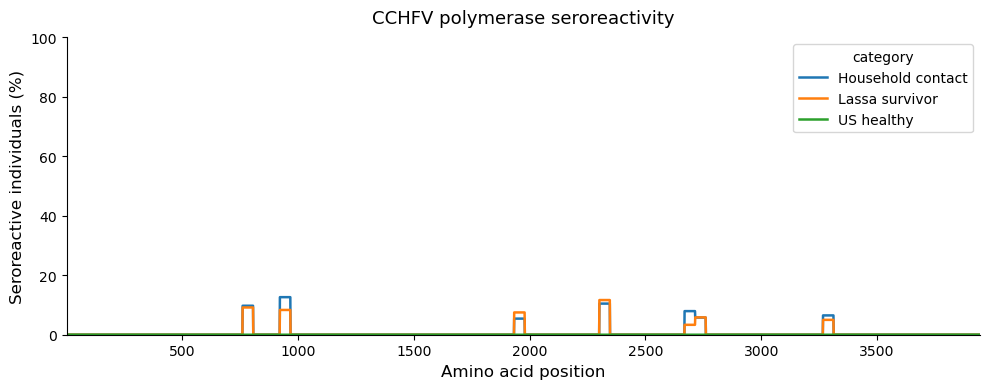

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data= position_summary, 
    x='position', 
    y='pct_seroreactive', 
    hue='category', 
    linewidth=1.8, 
    ax=ax
)

ax.set_xlabel('Amino acid position', fontsize=12)
ax.set_ylabel('Seroreactive individuals (%)', fontsize=12)
ax.set_xlim(1, len(ref)) #minimum and maximum position
ax.set_ylim(0,  100)

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title('CCHFV polymerase seroreactivity', y=1.02, fontsize=13)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('CCHFV_polymerase_reactivity.svg', format='svg')
plt.show()

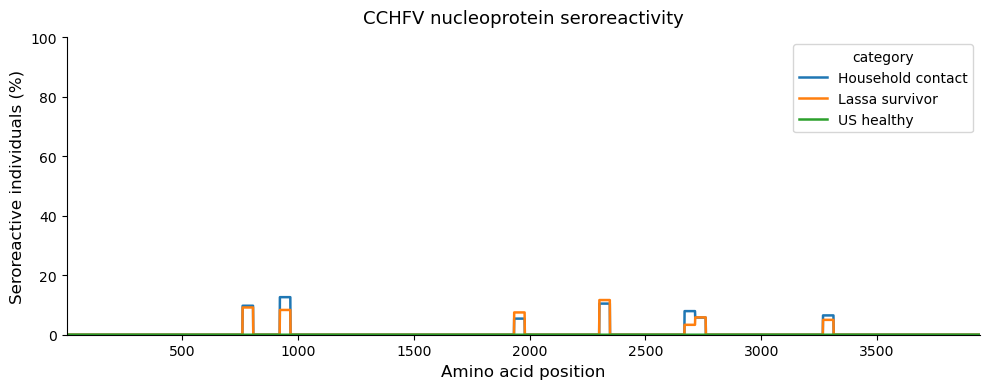

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data= position_summary, 
    x='position', 
    y='pct_seroreactive', 
    hue='category', 
    linewidth=1.8, 
    ax=ax
)

ax.set_xlabel('Amino acid position', fontsize=12)
ax.set_ylabel('Seroreactive individuals (%)', fontsize=12)
ax.set_xlim(1, len(ref)) #minimum and maximum position
ax.set_ylim(0,  100)

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title('CCHFV nucleoprotein seroreactivity', y=1.02, fontsize=13)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('CCHFV_nucleoprotein_reactivity.svg', format='svg')
plt.show()